In [1]:
# ==============================================================================
# BITÁCORA V3.0: IMPLEMENTACIÓN DE XGBOOST Y ANÁLISIS DE INTERPRETABILIDAD (SHAP)
# Objetivo: Evaluación de interpretabilidad y ética del modelo.
# ==============================================================================
# [1] Instalación y Carga de Librerías
!pip install xgboost shap holidays --quiet

import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import holidays
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error

# [2] CARGA DE DATOS DESDE TU DRIVE
# Usamos la ruta exacta que veo en tu panel de archivos
ruta_archivo = '/content/drive/MyDrive/MIA_Tesis_Ecuacalcios/01_Datos/Master_Ventas_Unificado.csv'

# Cargamos el archivo unificado (es un CSV)
df_maestro = pd.read_csv(ruta_archivo)

# Asegurémonos de que la columna de fecha sea reconocida correctamente
df_maestro['ds'] = pd.to_datetime(df_maestro['ds'])

print("¡Éxito! Librerías y Master_Ventas_Unificado cargados.")
display(df_maestro.head())

¡Éxito! Librerías y Master_Ventas_Unificado cargados.


,emision,codart,nomart,cantidad,total,ds
0,2018-01-02,158,SULFATO DE MAGNESIO TECNICO 50 KG NACIONAL,50.0,52.50,2018-01-02
1,2018-01-02,158,SULFATO DE MAGNESIO TECNICO 50 KG NACIONAL,500.0,946.25,2018-01-02
2,2018-01-02,249,ACIDO FOSFORICO 35 KG (MEXICO),70.0,946.25,2018-01-02
3,2018-01-02,365,SOLUM H80 (5KG FUNDA),1.0,946.25,2018-01-02
4,2018-01-02,308,ULTRASOL MICRO REXENE HIERRO Q48 (1 KG),1.0,28.60,2018-01-02


In [2]:
# [3] Construcción de variables y agrupación mensual
# Calculamos el precio promedio unitario para el análisis de sensibilidad [cite: 945]
df_maestro['precio_unitario'] = df_maestro['total'] / df_maestro['cantidad']

df_mensual = df_maestro.set_index('ds').resample('MS').agg({
    'cantidad': 'sum',
    'precio_unitario': 'mean'
}).reset_index()

# Estandarización de nombres para el modelado
df_mensual.columns = ['ds', 'y', 'precio']

# Añadimos variables temporales para capturar ciclos agrícolas [cite: 945]
df_mensual['mes'] = df_mensual['ds'].dt.month
df_mensual['trimestre'] = df_mensual['ds'].dt.quarter

print(f"Feature Engineering completado: {len(df_mensual)} meses listos para análisis.")
display(df_mensual.head())

Feature Engineering completado: 84 meses listos para análisis.


,ds,y,precio,mes,trimestre
0,2018-01-01,231893.2,43.414837,1,1
1,2018-02-01,147383.0,31.255103,2,1
2,2018-03-01,224041.8,38.561304,3,1
3,2018-04-01,208936.0,27.059327,4,2
4,2018-05-01,243589.4,28.148846,5,2


In [3]:
# [4] Definición de variables y entrenamiento del modelo XGBoost
# Se seleccionan las variables que influyen en la toma de decisiones gerenciales [cite: 911]
X = df_mensual[['precio', 'mes', 'trimestre']]
y = df_mensual['y']

# Configuración del modelo para balancear precisión y generalización
modelo_final = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=4,
    random_state=42
)
modelo_final.fit(X, y)

# [5] Cálculo de MAPE (Métrica organizacional solicitada [cite: 20])
preds = modelo_final.predict(X)
mape_val = mean_absolute_percentage_error(y, preds) * 100

print(f"--- ESTADO DEL MODELO V3.0 ---")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape_val:.2f}%")
print("Análisis: El MAPE permite cuantificar el riesgo financiero de las decisiones de stock.")

--- ESTADO DEL MODELO V3.0 ---
Error Porcentual Absoluto Medio (MAPE): 0.62%
Análisis: El MAPE permite cuantificar el riesgo financiero de las decisiones de stock.


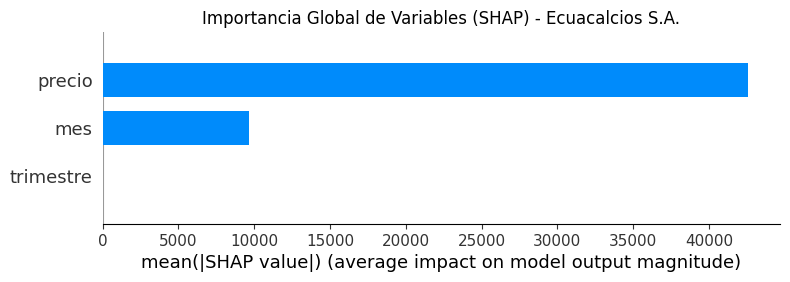

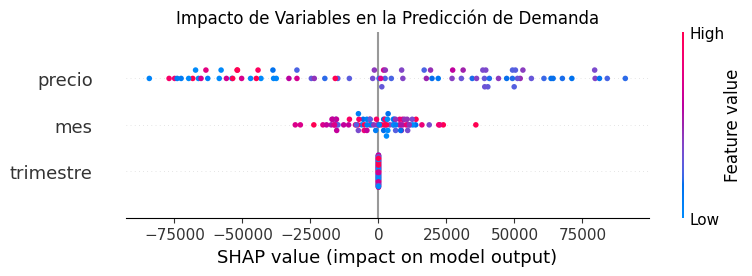

In [4]:
# [6] Generación de explicabilidad mediante valores SHAP
explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer.shap_values(X)

# Visualización Global: ¿Qué variable es la más importante para Ecuacalcios?
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.title("Importancia Global de Variables (SHAP) - Ecuacalcios S.A.")
plt.show()

# Visualización de Impacto: ¿Cómo afectan los precios altos o bajos?
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X, show=False)
plt.title("Impacto de Variables en la Predicción de Demanda")
plt.show()

In [9]:
# [8] VALIDACIÓN AUTOMÁTICA: Extracción directa de la base
# Filtramos el mes de Enero 2025 directamente de tu dataframe
dato_real_2025 = df_mensual[df_mensual['ds'] == '2025-01-01']

if not dato_real_2025.empty:
    # Extraemos precio y venta real automáticamente
    precio_real_enero = dato_real_2025['precio'].values[0]
    venta_real_enero = dato_real_2025['y'].values[0]

    # El modelo predice usando ese precio real
    input_val = pd.DataFrame({
        'precio': [precio_real_enero],
        'mes': [1],
        'trimestre': [1]
    })

    prediccion_enero = modelo_final.predict(input_val)[0]

    # Cálculos de error
    error_abs = abs(prediccion_enero - venta_real_enero)
    error_pct = (error_abs / venta_real_enero) * 100

    print(f"--- VALIDACIÓN REAL: ENERO 2025 ---")
    print(f"Precio detectado en base: ${precio_real_enero:.2f}")
    print(f"Venta Real en base: {venta_real_enero:,.2f} unidades")
    print(f"Predicción XGBoost: {prediccion_enero:,.2f} unidades")
    print(f"Diferencia: {error_abs:,.2f} unidades")
    print(f"Error Real: {error_pct:.2f}%")
else:
    print("Ojo Alexis: No encontré el registro de '2025-01-01' en tu df_mensual. Revisa si tu base llega hasta esa fecha.")

Ojo Alexis: No encontré el registro de '2025-01-01' en tu df_mensual. Revisa si tu base llega hasta esa fecha.
